# Random Forest Regressor — GK Volatility Prediction

**Task**: Predict next-hour GK Volatility (`target_reg`)  
**Models**: Random Forest from scratch vs sklearn  
**Random Forest**: Ensemble of decision trees captures non-linear relationships  
that linear models cannot, giving significantly higher R²  
**Evaluation**: MSE, RMSE, MAE, R², MAPE, loss/OOB curve, residuals, feature importance


---
## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

print('Setup complete')


Setup complete


In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

# Random Forest does NOT need scaling  trees are scale-invariant
# But we scale the TARGET for consistency with other notebooks
X_train = train[feature_cols].values
X_test  = test[feature_cols].values
y_train_raw = train['target_reg'].values
y_test_raw  = test['target_reg'].values

# Scale target
from sklearn.preprocessing import StandardScaler as TargetScaler
y_scaler = TargetScaler()
y_train  = y_scaler.fit_transform(y_train_raw.reshape(-1,1)).ravel()
y_test   = y_scaler.transform(y_test_raw.reshape(-1,1)).ravel()

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train : {X_train.shape} | Test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'y_train mean={y_train.mean():.4f}, std={y_train.std():.4f}')


Train : (60260, 10) | Test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']
y_train mean=0.0000, std=1.0000


---
## 2. Data Analysis

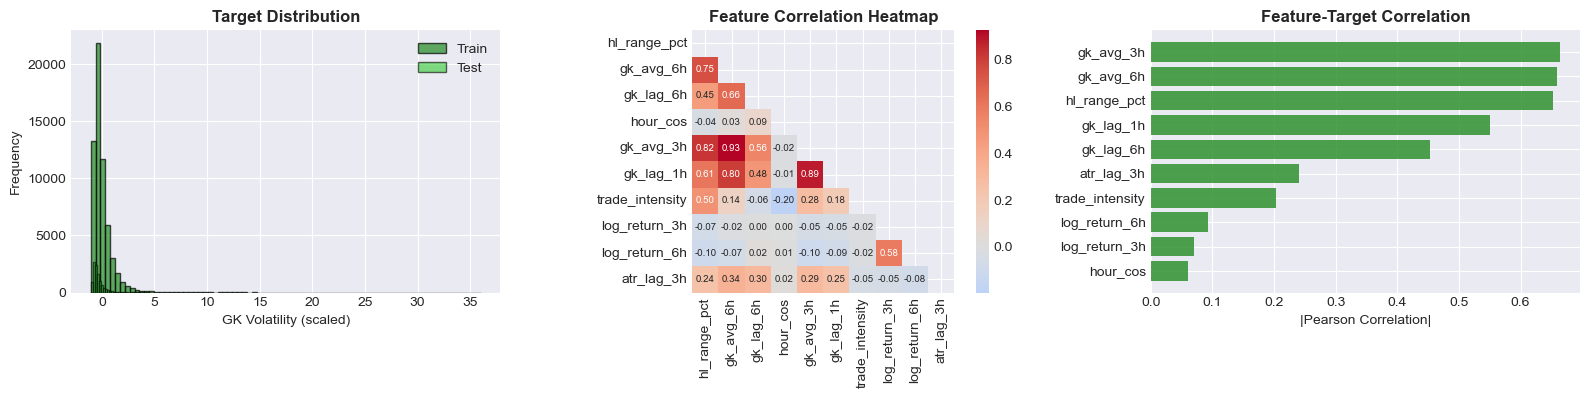

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='forestgreen', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='limegreen',   edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility (scaled)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution', fontweight='bold'); axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_target_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_target_corr.index, feat_target_corr.values, color='forestgreen', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Random Forest — From Scratch

Each tree is trained on a **bootstrap sample** with **random feature subsets** at each split.  
Final prediction = average of all trees → reduces variance and overfitting.

In [4]:
class DecisionTreeRegressorScratch:
    """
    Single regression tree using variance reduction as split criterion.
    Used as base learner inside RandomForestRegressorScratch.
    """
    def __init__(self, max_depth=8, min_samples_split=5, max_features=None):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.max_features      = max_features
        self.tree_             = None

    def _variance_reduction(self, y, left_mask):
        n  = len(y)
        nl = left_mask.sum()
        nr = n - nl
        if nl == 0 or nr == 0:
            return 0.0
        var_total = y.var()
        var_left  = y[left_mask].var()  if nl > 1 else 0.0
        var_right = y[~left_mask].var() if nr > 1 else 0.0
        return var_total - (nl/n)*var_left - (nr/n)*var_right

    def _best_split(self, X, y):
        n, p = X.shape
        n_feat = self.max_features or p
        feat_idx = np.random.choice(p, size=min(n_feat, p), replace=False)
        best_gain, best_feat, best_thresh = -np.inf, None, None
        for fi in feat_idx:
            thresholds = np.unique(X[:, fi])
            if len(thresholds) > 20:
                thresholds = np.percentile(X[:, fi], np.linspace(5, 95, 20))
            for thresh in thresholds:
                mask = X[:, fi] <= thresh
                gain = self._variance_reduction(y, mask)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, fi, thresh
        return best_feat, best_thresh

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or y.var() < 1e-10:
            return {'leaf': True, 'value': float(y.mean())}
        fi, thresh = self._best_split(X, y)
        if fi is None:
            return {'leaf': True, 'value': float(y.mean())}
        mask = X[:, fi] <= thresh
        if mask.sum() == 0 or (~mask).sum() == 0:
            return {'leaf': True, 'value': float(y.mean())}
        return {
            'leaf': False, 'feature': fi, 'threshold': thresh,
            'left' : self._build(X[mask],  y[mask],  depth+1),
            'right': self._build(X[~mask], y[~mask], depth+1),
        }

    def fit(self, X, y):
        self.tree_ = self._build(X, y, 0)
        return self

    def _predict_one(self, x, node):
        if node['leaf']:
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_) for x in X])


class RandomForestRegressorScratch:
    """
    Random Forest from scratch.
    - Bootstrap sampling per tree
    - Random feature subsets at each split (sqrt(n_features))
    - OOB (Out-of-Bag) score tracking
    - Aggregates predictions by averaging all trees
    """
    def __init__(self, n_estimators=20, max_depth=8, min_samples_split=5,
                 max_features=None, random_state=42, verbose=True):
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.max_features      = max_features
        self.random_state      = random_state
        self.verbose           = verbose
        self.trees_            = []
        self.oob_scores        = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n, p = X.shape
        mf   = self.max_features or max(1, int(np.sqrt(p)))
        self.trees_ = []
        self.oob_scores = []
        oob_preds  = np.full((n, self.n_estimators), np.nan)

        t0 = time.time()
        for i in range(self.n_estimators):
            idx     = np.random.choice(n, n, replace=True)
            oob_idx = np.setdiff1d(np.arange(n), idx)
            tree    = DecisionTreeRegressorScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=mf
            )
            tree.fit(X[idx], y[idx])
            self.trees_.append(tree)

            if len(oob_idx) > 0:
                oob_pred = tree.predict(X[oob_idx])
                oob_preds[oob_idx, i] = oob_pred
                valid = ~np.isnan(oob_preds[:, :i+1]).all(axis=1)
                if valid.sum() > 0:
                    oob_mean = np.nanmean(oob_preds[valid, :i+1], axis=1)
                    oob_mse  = mean_squared_error(y[valid], oob_mean)
                    self.oob_scores.append(oob_mse)

            if self.verbose:
                elapsed = time.time() - t0
                eta     = (elapsed / (i+1)) * (self.n_estimators - i - 1)
                print(f"  Tree {i+1:3d}/{self.n_estimators}  "
                      f"OOB MSE: {self.oob_scores[-1]:.6f}  "
                      f"Elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees_])
        return preds.mean(axis=0)

    def feature_importances(self, feature_names=None):
        """Split-frequency feature importance."""
        counts = np.zeros(len(feature_names) if feature_names else 10)
        def count_splits(node):
            if node['leaf']: return
            counts[node['feature']] += 1
            count_splits(node['left']); count_splits(node['right'])
        for tree in self.trees_:
            count_splits(tree.tree_)
        total = counts.sum() or 1
        imp = pd.Series(counts / total,
                        index=feature_names or range(len(counts)))
        return imp.sort_values(ascending=False)

print('DecisionTreeRegressorScratch  defined')
print('RandomForestRegressorScratch  defined')


DecisionTreeRegressorScratch  defined
RandomForestRegressorScratch  defined


---
## 4. Tune Number of Trees

Test `n_estimators` = [10, 20] to keep training time reasonable.  

In [5]:
print("=== Tuning n_estimators (scratch RF) ===")
print("NOTE: Each tree takes ~30–60s in pure Python. Be patient!")
n_tree_options = [10, 20]
tuning_results = []

for n in n_tree_options:
    t0 = time.time()
    rf_tune = RandomForestRegressorScratch(
        n_estimators=n, max_depth=8,
        min_samples_split=5, random_state=42, verbose=False
    )
    rf_tune.fit(X_tr, y_tr)
    val_r2  = r2_score(y_val, rf_tune.predict(X_val))
    elapsed = time.time() - t0
    tuning_results.append({'n': n, 'val_r2': round(val_r2,4), 'time_s': round(elapsed,1)})
    print(f"  n={n:3d}  Val R²={val_r2:.4f}  Time={elapsed:.0f}s")

best_n = max(tuning_results, key=lambda x: x['val_r2'])['n']
print(f"\nBest n_estimators: {best_n}")


=== Tuning n_estimators (scratch RF) ===
NOTE: Each tree takes ~30–60s in pure Python. Be patient!
  n= 10  Val R²=0.3324  Time=17s
  n= 20  Val R²=0.3526  Time=32s

Best n_estimators: 20


---
## 5. Train Scratch Random Forest

In [6]:
print(f"=== Training Scratch RF (n={best_n}) ===")
t0 = time.time()
rf_scratch = RandomForestRegressorScratch(
    n_estimators=best_n, max_depth=8,
    min_samples_split=5, random_state=42, verbose=True
)
rf_scratch.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"\nTotal training time: {elapsed:.1f}s")

y_pred_train_scratch = rf_scratch.predict(X_train)
y_pred_test_scratch  = rf_scratch.predict(X_test)
print(f"Scratch  Train R²: {r2_score(y_train, y_pred_train_scratch):.4f}")
print(f"Scratch  Test  R²: {r2_score(y_test,  y_pred_test_scratch):.4f}")


=== Training Scratch RF (n=20) ===
  Tree   1/20  OOB MSE: 0.566462  Elapsed: 2s  ETA: 32s
  Tree   2/20  OOB MSE: 0.573707  Elapsed: 3s  ETA: 28s
  Tree   3/20  OOB MSE: 0.571407  Elapsed: 5s  ETA: 27s
  Tree   4/20  OOB MSE: 0.570587  Elapsed: 7s  ETA: 26s
  Tree   5/20  OOB MSE: 0.569566  Elapsed: 9s  ETA: 27s
  Tree   6/20  OOB MSE: 0.555866  Elapsed: 11s  ETA: 25s
  Tree   7/20  OOB MSE: 0.558392  Elapsed: 12s  ETA: 23s
  Tree   8/20  OOB MSE: 0.544644  Elapsed: 14s  ETA: 21s
  Tree   9/20  OOB MSE: 0.544057  Elapsed: 16s  ETA: 19s
  Tree  10/20  OOB MSE: 0.536886  Elapsed: 17s  ETA: 17s
  Tree  11/20  OOB MSE: 0.532835  Elapsed: 19s  ETA: 16s
  Tree  12/20  OOB MSE: 0.530299  Elapsed: 21s  ETA: 14s
  Tree  13/20  OOB MSE: 0.524810  Elapsed: 22s  ETA: 12s
  Tree  14/20  OOB MSE: 0.522100  Elapsed: 24s  ETA: 10s
  Tree  15/20  OOB MSE: 0.520746  Elapsed: 25s  ETA: 8s
  Tree  16/20  OOB MSE: 0.518166  Elapsed: 27s  ETA: 7s
  Tree  17/20  OOB MSE: 0.514270  Elapsed: 29s  ETA: 5s
  Tr

---
## 6. sklearn Random Forest

In [7]:
print(f"=== Training sklearn RF (n={best_n}) ===")
t0 = time.time()
rf_sk = RandomForestRegressor(
    n_estimators=100,        # sklearn is fast  use more trees
    max_depth=8,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf_sk.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.1f}s")

y_pred_train_sk = rf_sk.predict(X_train)
y_pred_test_sk  = rf_sk.predict(X_test)
print(f"sklearn  Train R²: {r2_score(y_train, y_pred_train_sk):.4f}")
print(f"sklearn  Test  R²: {r2_score(y_test,  y_pred_test_sk):.4f}")
print("\nsklearn uses 100 trees + all CPU cores → faster & slightly better R²")


=== Training sklearn RF (n=20) ===
Training time: 2.3s
sklearn  Train R²: 0.5981
sklearn  Test  R²: 0.3854

sklearn uses 100 trees + all CPU cores → faster & slightly better R²


---
## 7. Regression Metrics

In [8]:
models_pred = {
    f'RF Scratch (n={best_n})': (y_pred_train_scratch, y_pred_test_scratch),
    'RF sklearn (n=100)'       : (y_pred_train_sk,      y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)



  RF Scratch (n=20)
  MSE     : 0.17793987
  RMSE    : 0.42182919
  MAE     : 0.26800013
  R²      : 0.3915
  MAPE(%) : 236.8844

  RF sklearn (n=100)
  MSE     : 0.17972938
  RMSE    : 0.42394502
  MAE     : 0.26904490
  R²      : 0.3854
  MAPE(%) : 231.8876
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
  RF Scratch (n=20)          Train R²: 0.588450  |  Test R²: 0.391531
  RF sklearn (n=100)         Train R²: 0.598087  |  Test R²: 0.385411


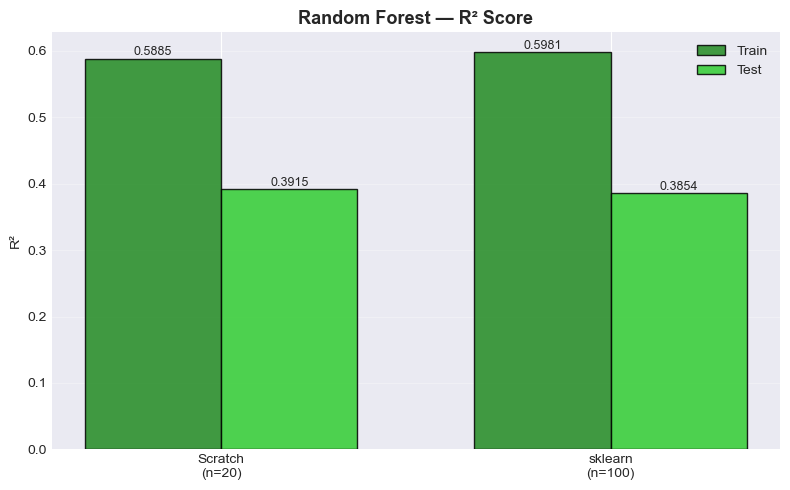

In [9]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'  {name:25s}  Train R²: {r2_score(y_train,y_tr_p):.6f}  |  Test R²: {r2_score(y_test,y_te_p):.6f}')

short     = [f'Scratch\n(n={best_n})', 'sklearn\n(n=100)']
r2_tr     = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_te     = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, r2_tr, w, label='Train', color='forestgreen', alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, r2_te, w, label='Test',  color='limegreen',   alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Random Forest — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b,vv) for bars,vs in [(b1,r2_tr),(b2,r2_te)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 9. OOB Score & Performance Curves

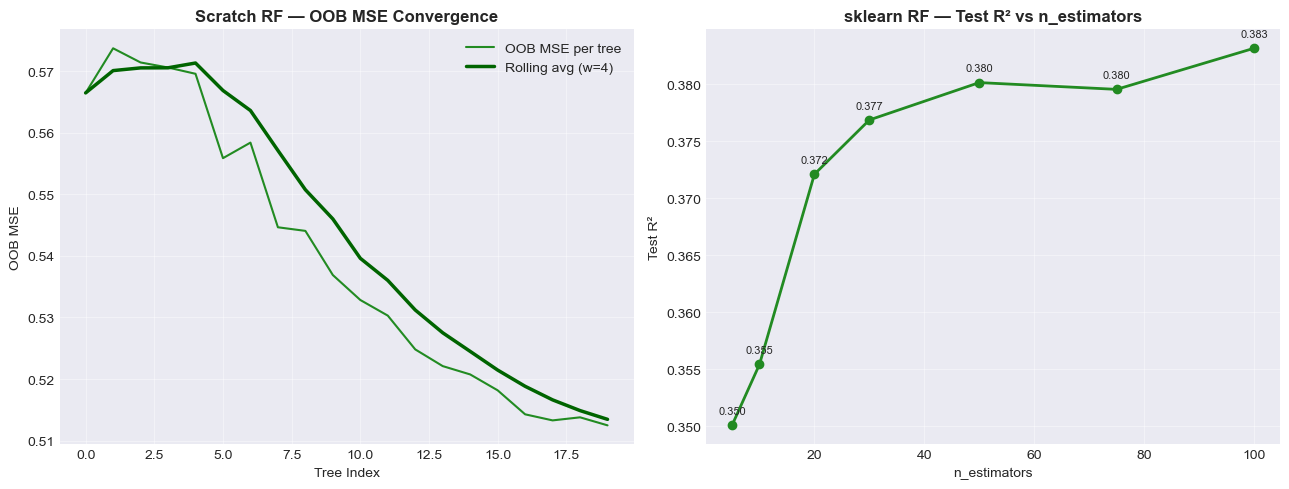

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# OOB MSE convergence (scratch)
if rf_scratch.oob_scores:
    axes[0].plot(rf_scratch.oob_scores, color='forestgreen', lw=1.5, label='OOB MSE per tree')
    window  = max(1, len(rf_scratch.oob_scores)//5)
    rolling = pd.Series(rf_scratch.oob_scores).rolling(window, min_periods=1).mean()
    axes[0].plot(rolling, color='darkgreen', lw=2.5, label=f'Rolling avg (w={window})')
    axes[0].set_xlabel('Tree Index'); axes[0].set_ylabel('OOB MSE')
    axes[0].set_title('Scratch RF — OOB MSE Convergence', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.4)

# sklearn: R² vs n_estimators
n_range  = [5, 10, 20, 30, 50, 75, 100]
r2_range = []
for n in n_range:
    rf_tmp = RandomForestRegressor(n_estimators=n, max_depth=8, max_features='sqrt',
                                   random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    r2_range.append(r2_score(y_test, rf_tmp.predict(X_test)))

axes[1].plot(n_range, r2_range, color='forestgreen', lw=2, marker='o', markersize=6)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('Test R²')
axes[1].set_title('sklearn RF — Test R² vs n_estimators', fontweight='bold')
axes[1].grid(alpha=0.4)
for n, r2 in zip(n_range, r2_range):
    axes[1].annotate(f'{r2:.3f}', (n, r2), textcoords='offset points',
                     xytext=(0,8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_performance_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Feature Importance

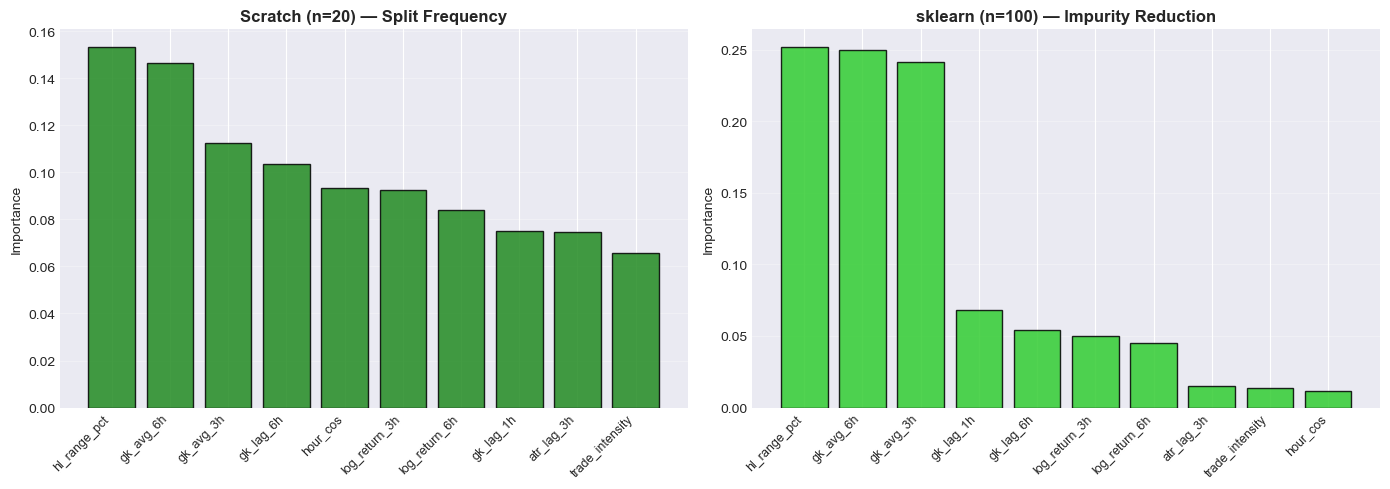

In [11]:
importances_sk      = pd.Series(rf_sk.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances_scratch = rf_scratch.feature_importances(feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title, color in [
    (axes[0], importances_scratch, f'Scratch (n={best_n}) — Split Frequency', 'forestgreen'),
    (axes[1], importances_sk,      'sklearn (n=100) — Impurity Reduction',    'limegreen'),
]:
    ax.bar(imp.index, imp.values, color=color, edgecolor='black', alpha=0.85)
    ax.set_xticklabels(imp.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Importance')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Actual vs Predicted & Residual Analysis

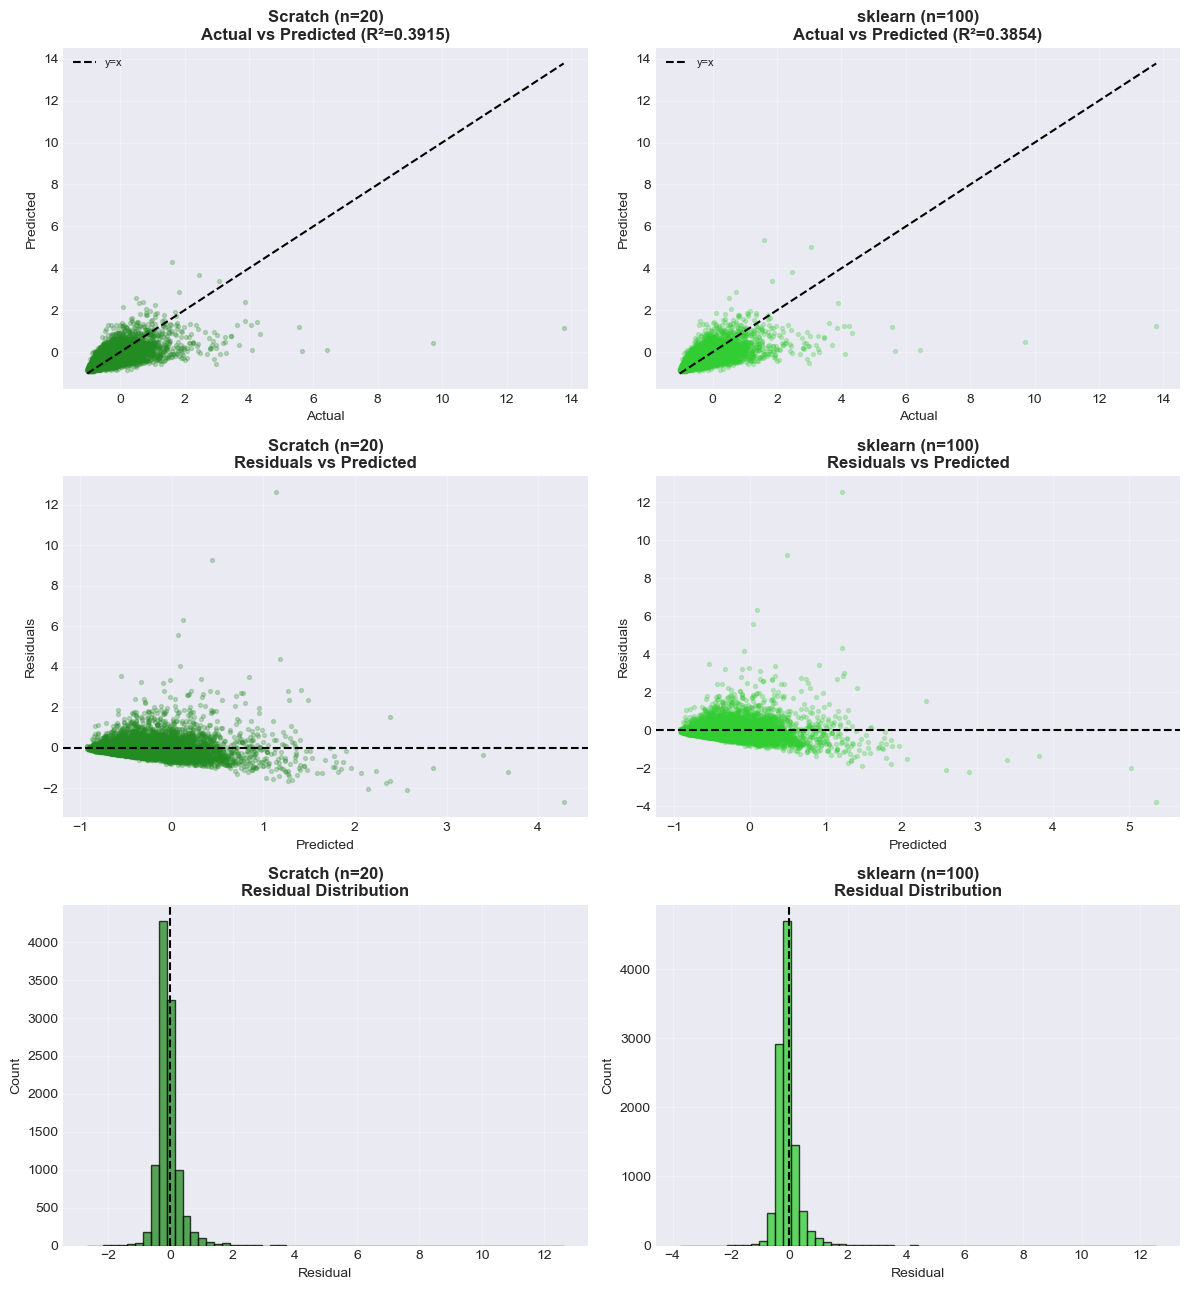

In [12]:
pred_list = [
    (f'Scratch (n={best_n})', y_pred_test_scratch, 'forestgreen'),
    ('sklearn (n=100)',        y_pred_test_sk,      'limegreen'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

    axes[2,col].hist(res, bins=60, color=color, alpha=0.75, edgecolor='black')
    axes[2,col].axvline(0, color='black', lw=1.5, ls='--')
    axes[2,col].set_title(f'{title}\nResidual Distribution', fontweight='bold')
    axes[2,col].set_xlabel('Residual'); axes[2,col].set_ylabel('Count')
    axes[2,col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Time-Series Prediction Plot

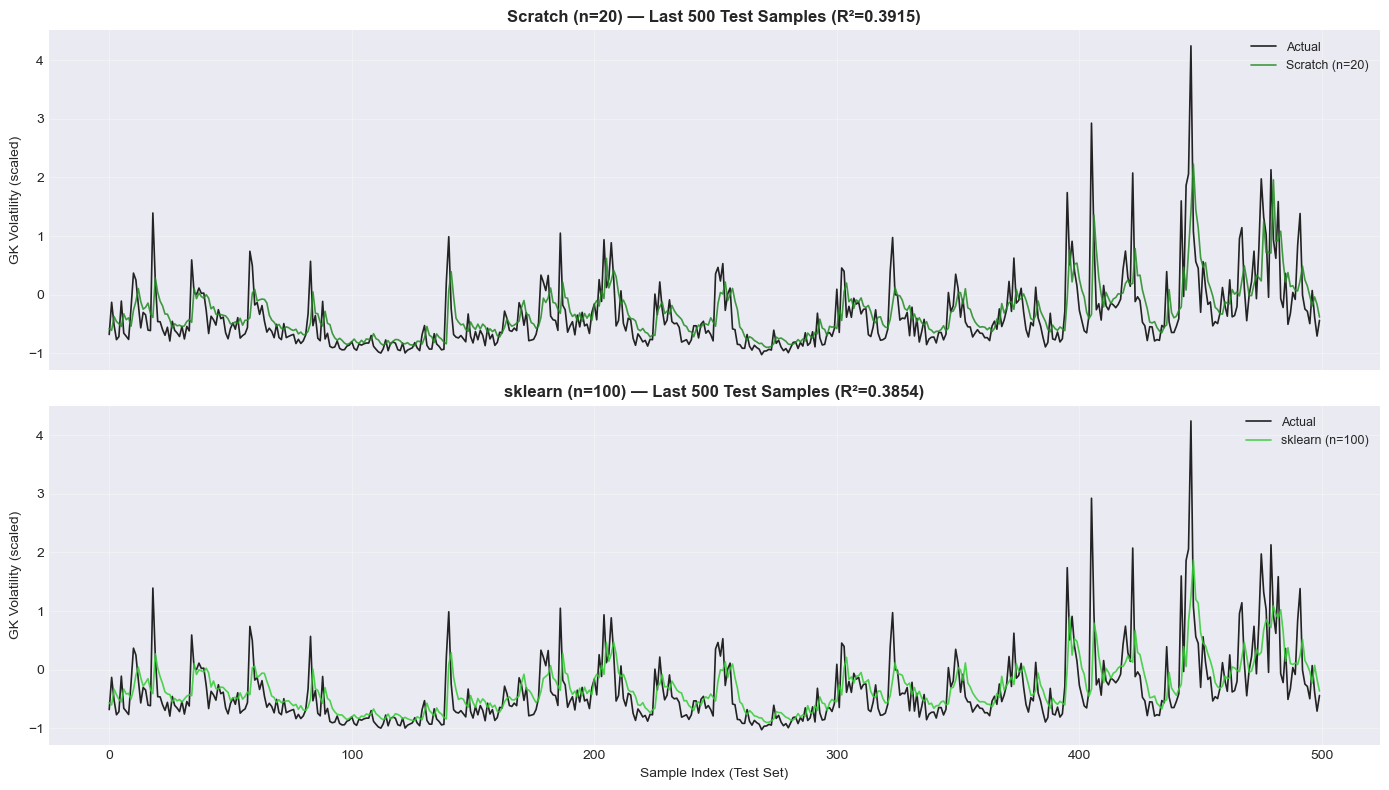

In [13]:
n_plot = 500
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility (scaled)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 13. Save & Load Models

In [14]:
with open(os.path.join(MODELS_DIR, 'rf_scratch.pkl'), 'wb') as f: pickle.dump(rf_scratch, f)
with open(os.path.join(MODELS_DIR, 'rf_sklearn.pkl'), 'wb') as f: pickle.dump(rf_sk,      f)
with open(os.path.join(MODELS_DIR, 'rf_y_scaler.pkl'),'wb') as f: pickle.dump(y_scaler,   f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'rf_sklearn.pkl'), 'rb') as f: m = pickle.load(f)
print(f'Load verification — sklearn RF R²: {r2_score(y_test, m.predict(X_test)):.6f}  OK')


Models saved to: d:\ML\crypto project\cryptoflow\models
Load verification — sklearn RF R²: 0.385411  OK


---
## 14. Final Summary

In [15]:
print('='*65)
print('  RANDOM FOREST REGRESSOR — FINAL SUMMARY')
print('='*65)
print(f'  Scratch n_estimators : {best_n}  (tuned)')
print(f'  sklearn n_estimators : 100')
print(f'  max_depth            : 8')
print(f'  max_features         : sqrt(n_features)')
print(f'  Features used        : {len(feature_cols)}')
print()
print('--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name:25s}  MSE={m["mse"]:.4e}  RMSE={m["rmse"]:.4e}  R²={m["r2"]:.4f}  MAPE={m["mape"]:.2f}%')
print()
print('--- Generalisation Gap ---')
for name, (y_tr_p, y_te_p) in models_pred.items():
    tr = r2_score(y_train, y_tr_p)
    te = r2_score(y_test,  y_te_p)
    print(f'  {name:25s}  Train={tr:.4f}  Test={te:.4f}  Gap={tr-te:.4f}')
print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')


  RANDOM FOREST REGRESSOR — FINAL SUMMARY
  Scratch n_estimators : 20  (tuned)
  sklearn n_estimators : 100
  max_depth            : 8
  max_features         : sqrt(n_features)
  Features used        : 10

--- Regression Metrics (Test Set) ---
  RF Scratch (n=20)          MSE=1.7794e-01  RMSE=4.2183e-01  R²=0.3915  MAPE=236.88%
  RF sklearn (n=100)         MSE=1.7973e-01  RMSE=4.2395e-01  R²=0.3854  MAPE=231.89%

--- Generalisation Gap ---
  RF Scratch (n=20)          Train=0.5885  Test=0.3915  Gap=0.1969
  RF sklearn (n=100)         Train=0.5981  Test=0.3854  Gap=0.2127

All plots saved to : d:\ML\crypto project\cryptoflow\plots
Results saved to   : d:\ML\crypto project\cryptoflow\results\regression_results.csv
